In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)


PALETTE = {
    "train"  : "#4C72B0",
    "test"   : "#DD8452",
    "accent" : "#55A868",
    "bg"     : "#F8F9FA",
}

print("All libraries imported successfully.")

All libraries imported successfully.


In [32]:
df = pd.read_csv("crime_dataset_india.csv", on_bad_lines='skip')
print(f"\n Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()


 Loaded: 48,670 rows × 14 columns
Columns: ['Report Number', 'Date Reported', 'Date of Occurrence', 'Time of Occurrence', 'City', 'Crime Code', 'Crime Description', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed', 'Case Closed', 'Date Case Closed']


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [10]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe(include="all")

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48670 entries, 0 to 48669
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       48670 non-null  int64 
 1   Date Reported       48670 non-null  object
 2   Date of Occurrence  48670 non-null  object
 3   Time of Occurrence  48670 non-null  object
 4   City                48670 non-null  object
 5   Crime Code          48670 non-null  int64 
 6   Crime Description   48670 non-null  object
 7   Victim Age          48670 non-null  int64 
 8   Victim Gender       48670 non-null  object
 9   Weapon Used         41656 non-null  object
 10  Crime Domain        48670 non-null  object
 11  Police Deployed     48670 non-null  int64 
 12  Case Closed         48670 non-null  object
 13  Date Case Closed    24243 non-null  object
dtypes: int64(4), object(10)
memory usage: 5.2+ MB
None

Missing values:
 Report Number             0
Date

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
count,48670.000000,48670,48670,48670,48670,48670.000000,48670,48670.000000,48670,41656,48670,48670.000000,48670,24243
unique,NaN,25546,40160,39886,29,NaN,21,NaN,3,6,4,NaN,2,16011
top,NaN,03-01-2022 20:00,12-25-2021 10:00,14-10-2022 06:54,Delhi,NaN,BURGLARY,NaN,F,Knife,Other Crime,NaN,No,20-06-2022 17:00
freq,NaN,14,2,6,6582,NaN,2395,NaN,25278,7070,27779,NaN,24427,10
mean,20301.511712,NaN,NaN,NaN,NaN,349.536778,NaN,44.565708,NaN,NaN,NaN,9.999630,NaN,NaN
std,10591.969882,NaN,NaN,NaN,NaN,144.229665,NaN,20.237854,NaN,NaN,NaN,5.467738,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,100.000000,NaN,10.000000,NaN,NaN,NaN,1.000000,NaN,NaN
25%,12168.250000,NaN,NaN,NaN,NaN,225.000000,NaN,27.000000,NaN,NaN,NaN,5.000000,NaN,NaN
50%,20712.500000,NaN,NaN,NaN,NaN,349.000000,NaN,44.000000,NaN,NaN,NaN,10.000000,NaN,NaN
75%,27992.750000,NaN,NaN,NaN,NaN,474.000000,NaN,62.000000,NaN,NaN,NaN,15.000000,NaN,NaN


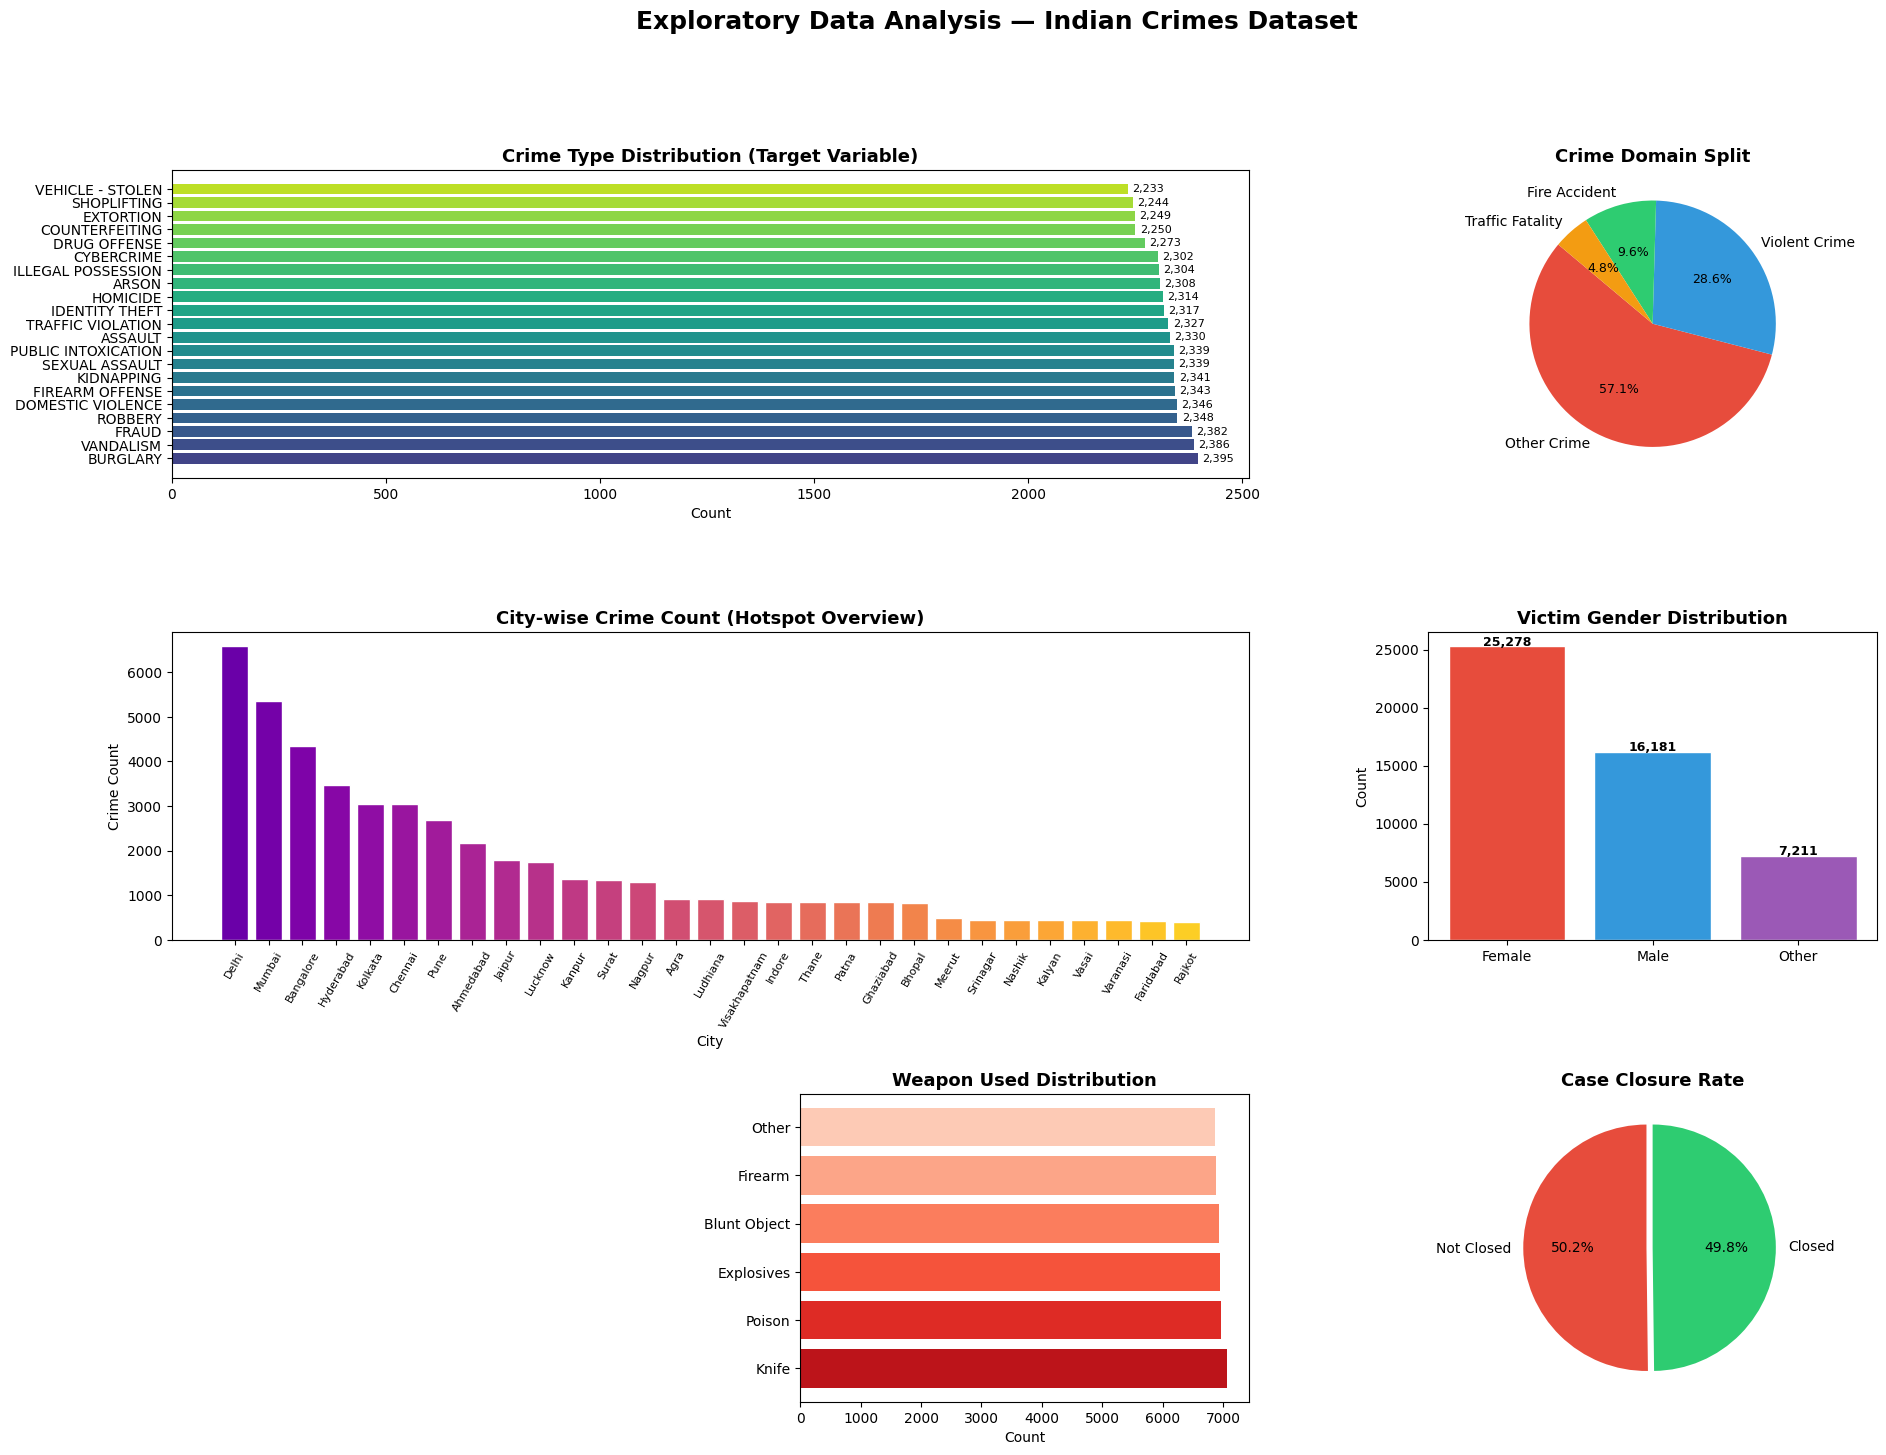

EDA saved → eda_overview.png


In [11]:
fig = plt.figure(figsize=(22, 16))
fig.suptitle("Exploratory Data Analysis — Indian Crimes Dataset",
             fontsize=18, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# Plot 1: Crime Description (Target) distribution
ax1 = fig.add_subplot(gs[0, :2])
crime_counts = df["Crime Description"].value_counts()
bars = ax1.barh(crime_counts.index, crime_counts.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(crime_counts))))
ax1.set_title("Crime Type Distribution (Target Variable)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Count")
for bar, val in zip(bars, crime_counts.values):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=8)

# Plot 2: Crime Domain pie
ax2 = fig.add_subplot(gs[0, 2])
domain_counts = df["Crime Domain"].value_counts()
wedges, texts, autotexts = ax2.pie(
    domain_counts.values, labels=domain_counts.index, autopct="%1.1f%%",
    colors=["#e74c3c","#3498db","#2ecc71","#f39c12"], startangle=140)
for at in autotexts: at.set_fontsize(9)
ax2.set_title("Crime Domain Split", fontsize=13, fontweight="bold")

ax3 = fig.add_subplot(gs[1, :2])
city_counts = df["City"].value_counts()
ax3.bar(city_counts.index, city_counts.values,
        color=plt.cm.plasma(np.linspace(0.2, 0.9, len(city_counts))), edgecolor="white")
ax3.set_title("City-wise Crime Count (Hotspot Overview)", fontsize=13, fontweight="bold")
ax3.set_xlabel("City"); ax3.set_ylabel("Crime Count")
ax3.tick_params(axis="x", rotation=60, labelsize=8)

# Plot 4: Victim Gender
ax4 = fig.add_subplot(gs[1, 2])
gender_map = {"M": "Male", "F": "Female", "X": "Other"}
gc = df["Victim Gender"].map(gender_map).value_counts()
ax4.bar(gc.index, gc.values, color=["#e74c3c","#3498db","#9b59b6"], edgecolor="white")
ax4.set_title("Victim Gender Distribution", fontsize=13, fontweight="bold")
ax4.set_ylabel("Count")
for i, v in enumerate(gc.values):
    ax4.text(i, v + 100, f"{v:,}", ha="center", fontsize=9, fontweight="bold")


# Plot 5: Weapon Used
ax6 = fig.add_subplot(gs[2, 1])
wc = df["Weapon Used"].value_counts()
ax6.barh(wc.index, wc.values,
         color=plt.cm.Reds_r(np.linspace(0.2, 0.8, len(wc))))
ax6.set_title("Weapon Used Distribution", fontsize=13, fontweight="bold")
ax6.set_xlabel("Count")

# Plot 6: Case Closed
ax7 = fig.add_subplot(gs[2, 2])
cc = df["Case Closed"].value_counts()
ax7.pie(cc.values, labels=["Not Closed","Closed"], autopct="%1.1f%%",
        colors=["#e74c3c","#2ecc71"], startangle=90, explode=[0.05, 0])
ax7.set_title("Case Closure Rate", fontsize=13, fontweight="bold")

plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA saved → eda_overview.png")

In [12]:
# ---- 3a. Drop columns that leak the target or are pure identifiers
DROP_COLS = ["Report Number", "Date Reported", "Date of Occurrence",
             "Date Case Closed", "Crime Description", "Crime Code"]
df.drop(columns=DROP_COLS, inplace=True)

# ---- 3b. Extract hour from Time of Occurrence  (HH:MM or HH:MM:SS)
df["Hour"] = pd.to_datetime(
    df["Time of Occurrence"], format="%H:%M", errors="coerce"
).dt.hour.fillna(0).astype(int)
df.drop(columns=["Time of Occurrence"], inplace=True)

# ---- 3c. Fill missing values
df["Weapon Used"].fillna("Unknown", inplace=True)

# ---- 3d. Encode categorical features
le = LabelEncoder()
CAT_COLS = ["City", "Victim Gender", "Weapon Used", "Case Closed"]
for col in CAT_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

# ---- 3e. Target  → Crime Domain  (4 classes)
TARGET = "Crime Domain"
df[TARGET] = le.fit_transform(df[TARGET].astype(str))
CLASS_NAMES = le.classes_           # keep for later plots

print("Class labels :", CLASS_NAMES)
print(f"\nFeature matrix shape : {df.drop(columns=[TARGET]).shape}")
df.head()

Class labels : ['Fire Accident' 'Other Crime' 'Traffic Fatality' 'Violent Crime']

Feature matrix shape : (48670, 7)


/tmp/ipykernel_1751/939048065.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weapon Used"].fillna("Unknown", inplace=True)


,City,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Hour
0,1,16,1,0,3,13,0,0
1,4,37,1,5,1,9,0,0
2,15,48,0,0,1,15,0,0
3,21,49,0,2,1,1,1,0
4,21,30,0,4,1,18,1,0


In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 36502
Testing  samples : 12168


In [14]:
rf = RandomForestClassifier(
    n_estimators   = 200,
    max_depth      = 15,
    min_samples_split = 5,
    class_weight   = "balanced",
    random_state   = 42,
    n_jobs         = -1,
)

print("Training Random Forest …")
rf.fit(X_train, y_train)
print("Training complete.")

Training Random Forest …
Training complete.


In [15]:
def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy"  : accuracy_score(y, y_pred),
        "Precision" : precision_score(y, y_pred, average="weighted", zero_division=0),
        "Recall"    : recall_score(y, y_pred, average="weighted", zero_division=0),
    }

train_metrics = compute_metrics(rf, X_train, y_train)
test_metrics  = compute_metrics(rf, X_test,  y_test)

print("\nTrain Metrics :", train_metrics)
print("Test  Metrics :", test_metrics)

# Detailed classification report on test set



Train Metrics : {'Accuracy': 0.9171278286121308, 'Precision': 0.9197793048651844, 'Recall': 0.9171278286121308}
Test  Metrics : {'Accuracy': 0.5746219592373438, 'Precision': 0.5585423077995563, 'Recall': 0.5746219592373438}

Classification Report (Test Set):
                  precision    recall  f1-score   support

   Fire Accident       0.40      0.32      0.36      1163
     Other Crime       0.65      0.74      0.69      6945
Traffic Fatality       0.33      0.27      0.30       582
   Violent Crime       0.46      0.39      0.42      3478

        accuracy                           0.57     12168
       macro avg       0.46      0.43      0.44     12168
    weighted avg       0.56      0.57      0.56     12168



## Part 2 – SVM & Neural Network (added)

Train two additional classifiers on the **same preprocessed data** as Random Forest, then compare all three models using four graphs.

In [18]:
# ── NEW MODELS ──────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import time

print("SVM and Neural Network libraries imported successfully.")

SVM and Neural Network libraries imported successfully.


In [19]:
# Feature scaling (required for SVM & Neural Network)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Features scaled. Shape:", X_train_sc.shape)

Features scaled. Shape: (36502, 7)


In [20]:
# ── Support Vector Machine ───────────────────────────────────
print("Training SVM (this may take a minute)…")
t0 = time.time()
svm = SVC(
    kernel       = "rbf",
    C            = 5,
    gamma        = "scale",
    class_weight = "balanced",
    random_state = 42,
    probability  = False,
)
svm.fit(X_train_sc, y_train)
print(f"SVM trained in {time.time()-t0:.1f}s")

Training SVM (this may take a minute)…
SVM trained in 84.8s


In [21]:
# ── Neural Network (MLP) ─────────────────────────────────────
print("Training Neural Network…")
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes = (256, 128, 64),
    activation         = "relu",
    solver             = "adam",
    max_iter           = 300,
    early_stopping     = True,
    validation_fraction= 0.1,
    random_state       = 42,
    verbose            = False,
)
mlp.fit(X_train_sc, y_train)
print(f"Neural Network trained in {time.time()-t0:.1f}s  |  Iterations: {mlp.n_iter_}")

Training Neural Network…
Neural Network trained in 14.3s  |  Iterations: 12


In [27]:
# ── Collect metrics for all three models ─────────────────────
def compute_metrics_generic(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy"  : accuracy_score(y, y_pred),
        "Precision" : precision_score(y, y_pred, average="weighted", zero_division=0),
        "Recall"    : recall_score(y, y_pred, average="weighted", zero_division=0),
    }

# Random Forest (uses un-scaled data)
rf_train  = compute_metrics_generic(rf,  X_train,    y_train)
rf_test   = compute_metrics_generic(rf,  X_test,     y_test)

# SVM (scaled data)
svm_train = compute_metrics_generic(svm, X_train_sc, y_train)
svm_test  = compute_metrics_generic(svm, X_test_sc,  y_test)

# Neural Network (scaled data)
mlp_train = compute_metrics_generic(mlp, X_train_sc, y_train)
mlp_test  = compute_metrics_generic(mlp, X_test_sc,  y_test)

all_results = {
    "Random Forest": {"train": rf_train,  "test": rf_test},
    "SVM"          : {"train": svm_train, "test": svm_test},
    "Neural Network": {"train": mlp_train, "test": mlp_test},
}

print(f"{'Model':<16} {'Set':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10}")
print("-"*56)
for model_name, splits in all_results.items():
    for split, m in splits.items():
        print(f"{model_name:<16} {split:<6} {m['Accuracy']:>10.4f} {m['Precision']:>10.4f} {m['Recall']:>10.4f}")



Model            Set      Accuracy  Precision     Recall
--------------------------------------------------------
Random Forest    train      0.9171     0.9198     0.9171
Random Forest    test       0.5746     0.5585     0.5746
SVM              train      0.2803     0.4742     0.2803
SVM              test       0.2370     0.4226     0.2370
Neural Network   train      0.5708     0.3258     0.5708
Neural Network   test       0.5708     0.3258     0.5708


In [30]:
# Detailed reports
print("\n=== SVM — Classification Report (Test) ===")
print(classification_report(y_test, svm.predict(X_test_sc), target_names=CLASS_NAMES))
print("=== Neural Network — Classification Report (Test) ===")
print(classification_report(y_test, mlp.predict(X_test_sc), target_names=CLASS_NAMES))
y_pred_test = rf.predict(X_test)
print("\nRandomforest — Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))


=== SVM — Classification Report (Test) ===
                  precision    recall  f1-score   support

   Fire Accident       0.10      0.28      0.15      1163
     Other Crime       0.57      0.23      0.33      6945
Traffic Fatality       0.06      0.36      0.10       582
   Violent Crime       0.30      0.22      0.25      3478

        accuracy                           0.24     12168
       macro avg       0.26      0.27      0.21     12168
    weighted avg       0.42      0.24      0.28     12168

=== Neural Network — Classification Report (Test) ===
                  precision    recall  f1-score   support

   Fire Accident       0.00      0.00      0.00      1163
     Other Crime       0.57      1.00      0.73      6945
Traffic Fatality       0.00      0.00      0.00       582
   Violent Crime       0.00      0.00      0.00      3478

        accuracy                           0.57     12168
       macro avg       0.14      0.25      0.18     12168
    weighted avg       0.33

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Randomforest — Classification Report (Test Set):
                  precision    recall  f1-score   support

   Fire Accident       0.40      0.32      0.36      1163
     Other Crime       0.65      0.74      0.69      6945
Traffic Fatality       0.33      0.27      0.30       582
   Violent Crime       0.46      0.39      0.42      3478

        accuracy                           0.57     12168
       macro avg       0.46      0.43      0.44     12168
    weighted avg       0.56      0.57      0.56     12168



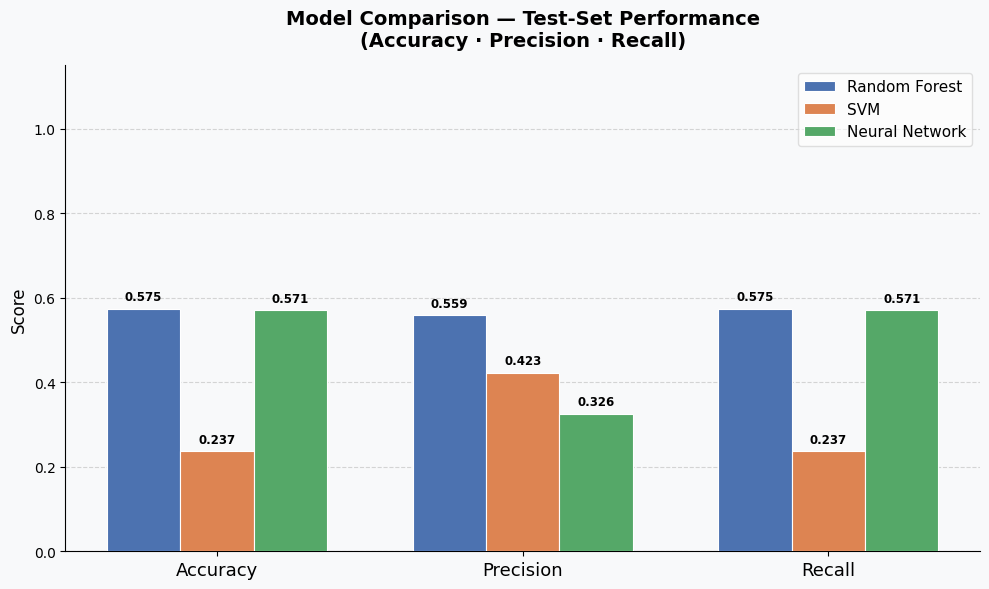

Plot saved → model_comparison_test.png


In [23]:
# ── Graph 1 : Test-set metric comparison (grouped bar) ───────
METRICS  = ["Accuracy", "Precision", "Recall"]
MODELS   = ["Random Forest", "SVM", "Neural Network"]
COLORS   = ["#4C72B0", "#DD8452", "#55A868"]

test_vals = {m: [all_results[m]["test"][k] for k in METRICS] for m in MODELS}

x     = np.arange(len(METRICS))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#F8F9FA")
ax.set_facecolor("#F8F9FA")

for i, (model, color) in enumerate(zip(MODELS, COLORS)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, test_vals[model], width,
                  label=model, color=color,
                  edgecolor="white", linewidth=0.8, zorder=3)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(METRICS, fontsize=13)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison — Test-Set Performance\n(Accuracy · Precision · Recall)",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(fontsize=11, framealpha=0.6)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("model_comparison_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → model_comparison_test.png")

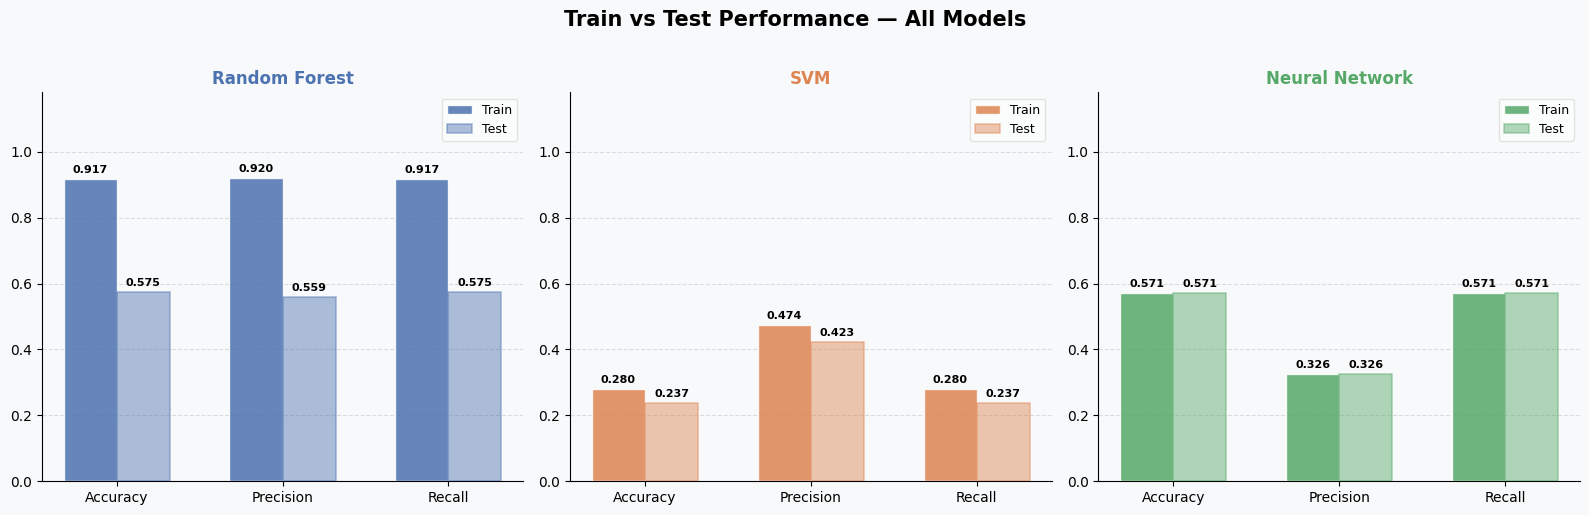

Plot saved → model_train_vs_test.png


In [24]:
# ── Graph 2 : Train vs Test per model (3-panel) ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#F8F9FA")
fig.suptitle("Train vs Test Performance — All Models",
             fontsize=15, fontweight="bold", y=1.02)

for ax, (model, color) in zip(axes, zip(MODELS, COLORS)):
    t_vals   = [all_results[model]["train"][k] for k in METRICS]
    te_vals  = [all_results[model]["test"][k]  for k in METRICS]
    x2       = np.arange(len(METRICS))
    w2       = 0.32

    ax.set_facecolor("#F8F9FA")
    b1 = ax.bar(x2 - w2/2, t_vals,  w2, label="Train",
                color=color, alpha=0.85, edgecolor="white", zorder=3)
    b2 = ax.bar(x2 + w2/2, te_vals, w2, label="Test",
                color=color, alpha=0.45, edgecolor=color,
                linewidth=1.2, zorder=3)

    for bars in (b1, b2):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.3f}",
                        xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_ylim(0, 1.18)
    ax.set_xticks(x2)
    ax.set_xticklabels(METRICS, fontsize=10)
    ax.set_title(model, fontsize=12, fontweight="bold", color=color)
    ax.legend(fontsize=9, framealpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("model_train_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → model_train_vs_test.png")

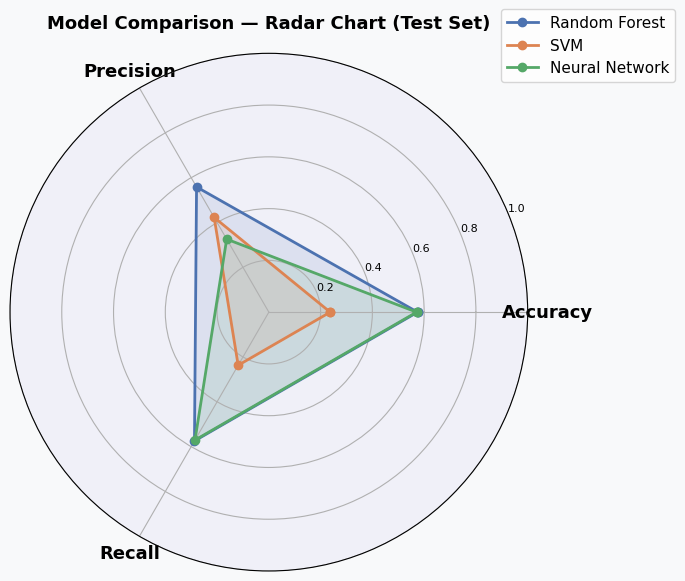

Plot saved → model_radar.png


In [25]:
# ── Graph 3 : Radar / Spider chart — test scores ─────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

categories = METRICS + [METRICS[0]]   # close the loop
N = len(METRICS)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7),
                       subplot_kw=dict(polar=True),
                       facecolor="#F8F9FA")
ax.set_facecolor("#F0F0F8")

for model, color in zip(MODELS, COLORS):
    vals = [all_results[model]["test"][k] for k in METRICS]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=color, label=model)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRICS, fontsize=13, fontweight="bold")
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Radar Chart (Test Set)",
             fontsize=13, fontweight="bold", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig("model_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → model_radar.png")

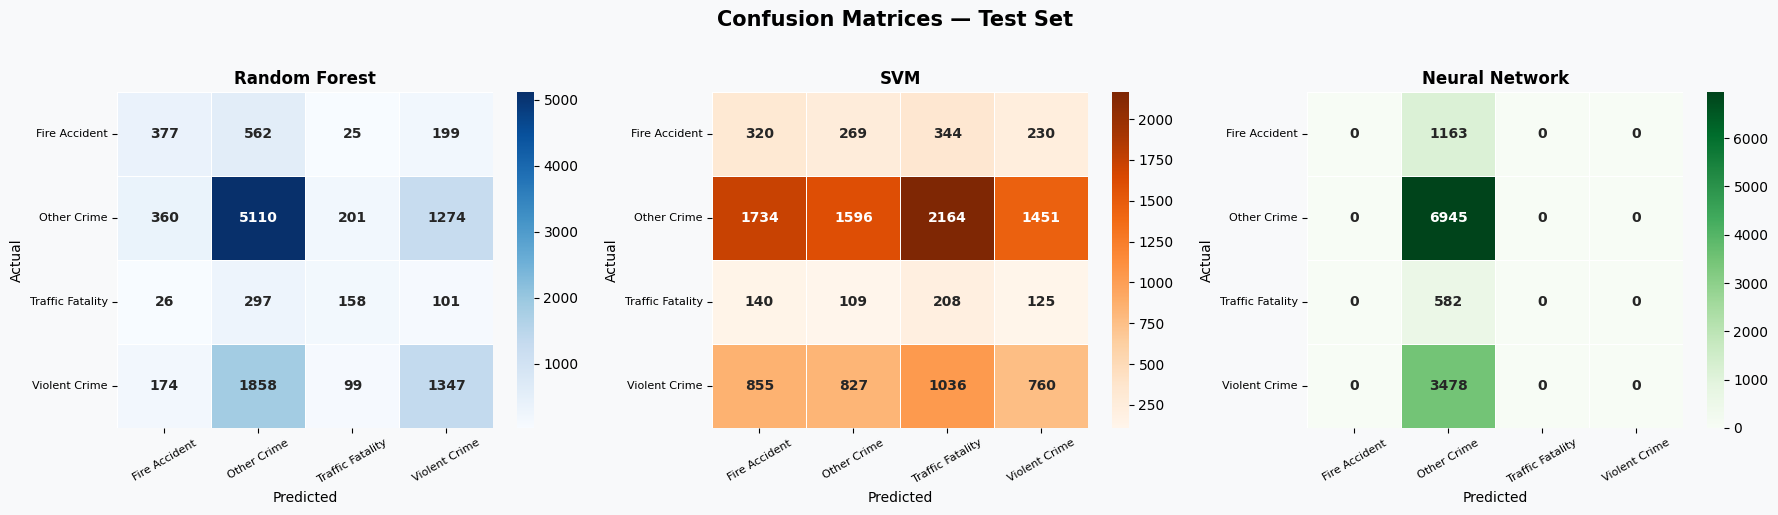

Plot saved → confusion_matrices.png


In [26]:
# ── Graph 4 : Confusion Matrices — side by side ──────────────
preds = {
    "Random Forest": rf.predict(X_test),
    "SVM"          : svm.predict(X_test_sc),
    "Neural Network": mlp.predict(X_test_sc),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#F8F9FA")
fig.suptitle("Confusion Matrices — Test Set",
             fontsize=15, fontweight="bold", y=1.02)

cmaps = ["Blues", "Oranges", "Greens"]
for ax, (model, y_pred_m), cmap in zip(axes, preds.items(), cmaps):
    cm = confusion_matrix(y_test, y_pred_m)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor="white",
                annot_kws={"size": 10, "weight": "bold"})
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → confusion_matrices.png")